In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Environment is ready!")

Environment is ready!


In [3]:
import os

print("Current folder:")
print(os.getcwd())

print("\nFiles and folders:")
print(os.listdir())

Current folder:
c:\zero-day-fraud-detection

Files and folders:
['.venv', '01_data_exploration.ipynb', 'data']


In [4]:
import os

for root, dirs, files in os.walk("data"):
    print("Folder:", root)
    for file in files:
        print("  File:", file)

Folder: data
  File: transactions_test.csv
  File: transactions_train.csv


In [5]:
import pandas as pd

train_path = "data/transactions_train.csv"
test_path = "data/transactions_test.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (300113, 21)
Test shape: (99887, 21)


In [1]:
import pandas as pd

paysim = pd.read_csv(
    "comparison/PS_20174392719_1491204439457_log.csv"
)

creditcard = pd.read_csv(
    "comparison/creditcard.csv"
)

print("PaySim:", paysim.shape)
print("Credit Card:", creditcard.shape)

PaySim: (6362620, 11)
Credit Card: (284807, 31)


In [4]:
print("===== PaySim =====")
print("Columns:", paysim.columns.tolist())
print("Fraud cases:", paysim["isFraud"].sum())
print("Fraud percentage:", paysim["isFraud"].mean() * 100)

print("\n===== Credit Card =====")
print("Columns:", creditcard.columns.tolist())
print("Fraud cases:", creditcard["Class"].sum())
print("Fraud percentage:", creditcard["Class"].mean() * 100)



===== PaySim =====
Columns: ['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']
Fraud cases: 8213
Fraud percentage: 0.12908204481801522

===== Credit Card =====
Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']
Fraud cases: 492
Fraud percentage: 0.1727485630620034


In [6]:
import pandas as pd

train_df = pd.read_csv("data/transactions_train.csv")
test_df = pd.read_csv("data/transactions_test.csv")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (300113, 21)
Test shape: (99887, 21)


In [7]:
print("Columns:")
print(train_df.columns.tolist())

Columns:
['transaction_id', 'transaction_time', 'customer_id', 'merchant_id', 'account_age_days', 'credit_score_band', 'kyc_level', 'avg_monthly_spend', 'merchant_risk_score', 'transaction_amount', 'payment_channel', 'device_type', 'is_international', 'ip_risk_score', 'txn_count_1h', 'txn_count_24h', 'failed_txn_count_24h', 'geo_distance_from_last_txn', 'amount_deviation_from_user_mean', 'is_fraud', 'post_auth_risk_score']


In [ ]:
print("Benchmark fraud cases:", train_df["is_fraud"].sum())
print("Benchmark fraud percentage:", train_df["is_fraud"].mean() * 100)

Benchmark fraud cases: 4871
Benchmark fraud percentage: 1.623055315831037


In [9]:
print("Benchmark train shape:", train_df.shape)

Benchmark train shape: (300113, 21)


In [1]:
import pandas as pd
import numpy as np

train_df = pd.read_csv("data/transactions_train.csv")
test_df = pd.read_csv("data/transactions_test.csv")

print("Train data shape:", train_df.shape)

Train data shape: (300113, 21)


Target Distribution (Class Imbalance Check)
In this step, we are counting how many transactions are Genuine (0) and how many are Fraud (1). This is very important because in the real world, fraud cases are very rare compared to normal transactions. We need to see this "Class Imbalance" visually so we can plan how to handle it before training our Deep Learning model.

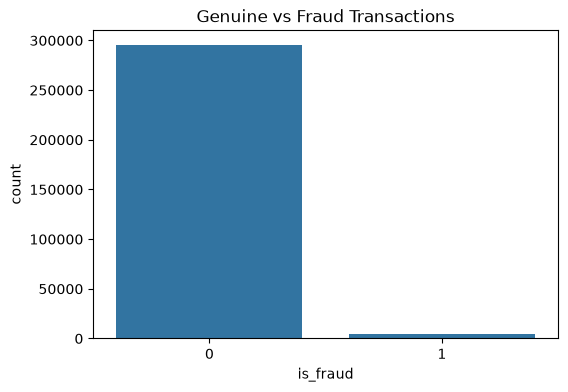

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.countplot(data=train_df, x='is_fraud')
plt.title('Genuine vs Fraud Transactions')
plt.show()

Behavioral Analysis (Transaction Amount)
In this step, we are checking if the transaction amount is different for fraud cases compared to genuine cases. This is important because our project is based on "behavior-based" detection. Finding differences in spending patterns will help our model detect zero-day fraud.

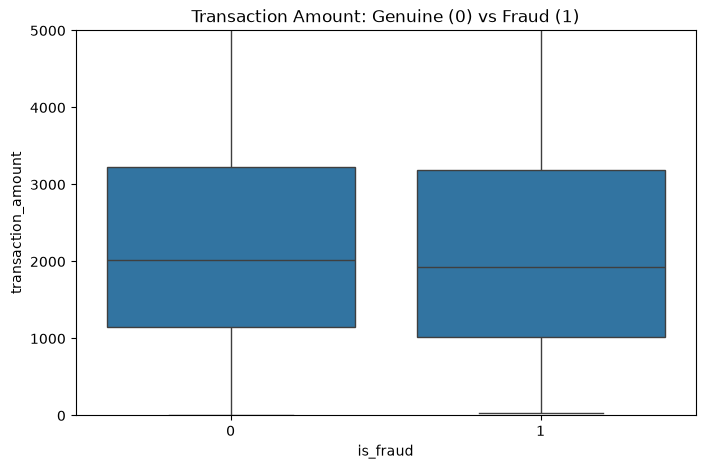

In [3]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=train_df, x='is_fraud', y='transaction_amount')
plt.title('Transaction Amount: Genuine (0) vs Fraud (1)')
plt.ylim(0, 5000)
plt.show()

Behavioral Analysis (Device Type vs Fraud)
Since the transaction amount alone does not show a massive difference between genuine and fraud transactions, we will now analyze a categorical behavioral feature: device_type. We want to see if fraudsters prefer using a specific type of device.

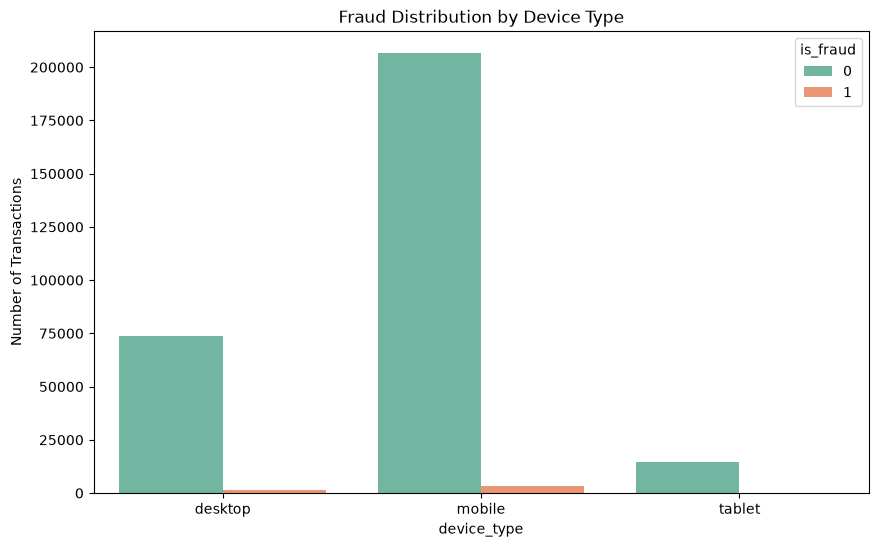

Fraud Percentage per Device Type:
device_type
desktop    1.620938
mobile     1.627700
tablet     1.568549
Name: is_fraud, dtype: float64


In [4]:
# Plotting the count of fraud and genuine transactions per device type
plt.figure(figsize=(10, 6))
sns.countplot(data=train_df, x='device_type', hue='is_fraud', palette='Set2')
plt.title('Fraud Distribution by Device Type')
plt.ylabel('Number of Transactions')
plt.show()

# Calculating the exact percentage of fraud for each device
print("Fraud Percentage per Device Type:")
print(train_df.groupby('device_type')['is_fraud'].mean() * 100)

Behavioral Analysis (International Transactions)
In this step, we will analyze the is_international feature. Fraudsters often use stolen card details across international borders to avoid legal jurisdiction. By checking the proportion of fraud in local versus international transactions, we can prove that geographic behavior is a crucial feature for our deep learning model.

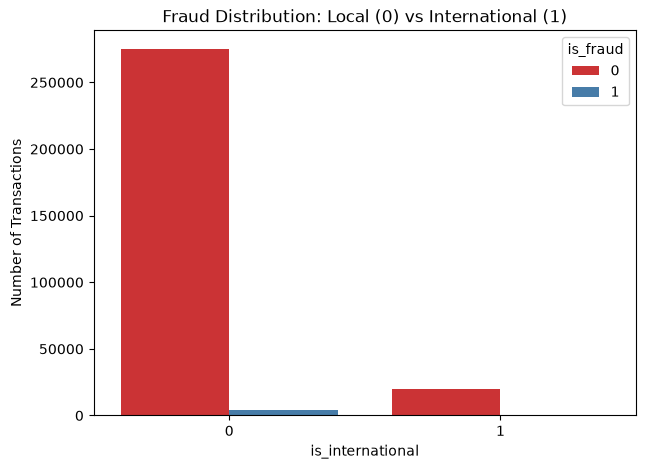

Fraud Percentage in Local vs International:
is_international
0    1.491266
1    3.397099
Name: is_fraud, dtype: float64


In [5]:
# Plotting the count of fraud and genuine transactions for Local vs International
plt.figure(figsize=(7, 5))
sns.countplot(data=train_df, x='is_international', hue='is_fraud', palette='Set1')
plt.title('Fraud Distribution: Local (0) vs International (1)')
plt.ylabel('Number of Transactions')
plt.show()

# Calculating the exact percentage
print("Fraud Percentage in Local vs International:")
print(train_df.groupby('is_international')['is_fraud'].mean() * 100)

Behavioral Analysis (Failed Transactions History)
In this final EDA step for our presentation, we will analyze the failed_txn_count_24h feature. We want to see if a high number of failed transactions in the last 24 hours is an indicator of fraudulent behavior. This is a classic behavioral pattern used to detect zero-day anomalies.

C:\Users\Windows 11\AppData\Local\Temp\ipykernel_4288\2755396338.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=train_df, x='is_fraud', y='failed_txn_count_24h', palette='muted')


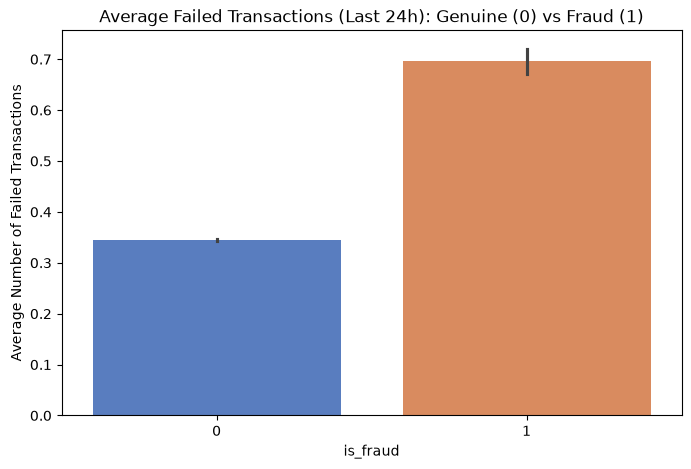

Average Failed Transactions in last 24h:
is_fraud
0    0.344866
1    0.695545
Name: failed_txn_count_24h, dtype: float64


In [6]:
plt.figure(figsize=(8, 5))
sns.barplot(data=train_df, x='is_fraud', y='failed_txn_count_24h', palette='muted')
plt.title('Average Failed Transactions (Last 24h): Genuine (0) vs Fraud (1)')
plt.ylabel('Average Number of Failed Transactions')
plt.show()

print("Average Failed Transactions in last 24h:")
print(train_df.groupby('is_fraud')['failed_txn_count_24h'].mean())

Correlation Heatmap (Final EDA Step)
To conclude our Data Exploration, we will create a Correlation Heatmap for all the numerical features. A heatmap shows how different numerical columns are mathematically related to each other and to our target variable (is_fraud). This helps us ensure there is no extreme multicollinearity (where two features are exactly the same) and helps us see which features influence fraud the most.

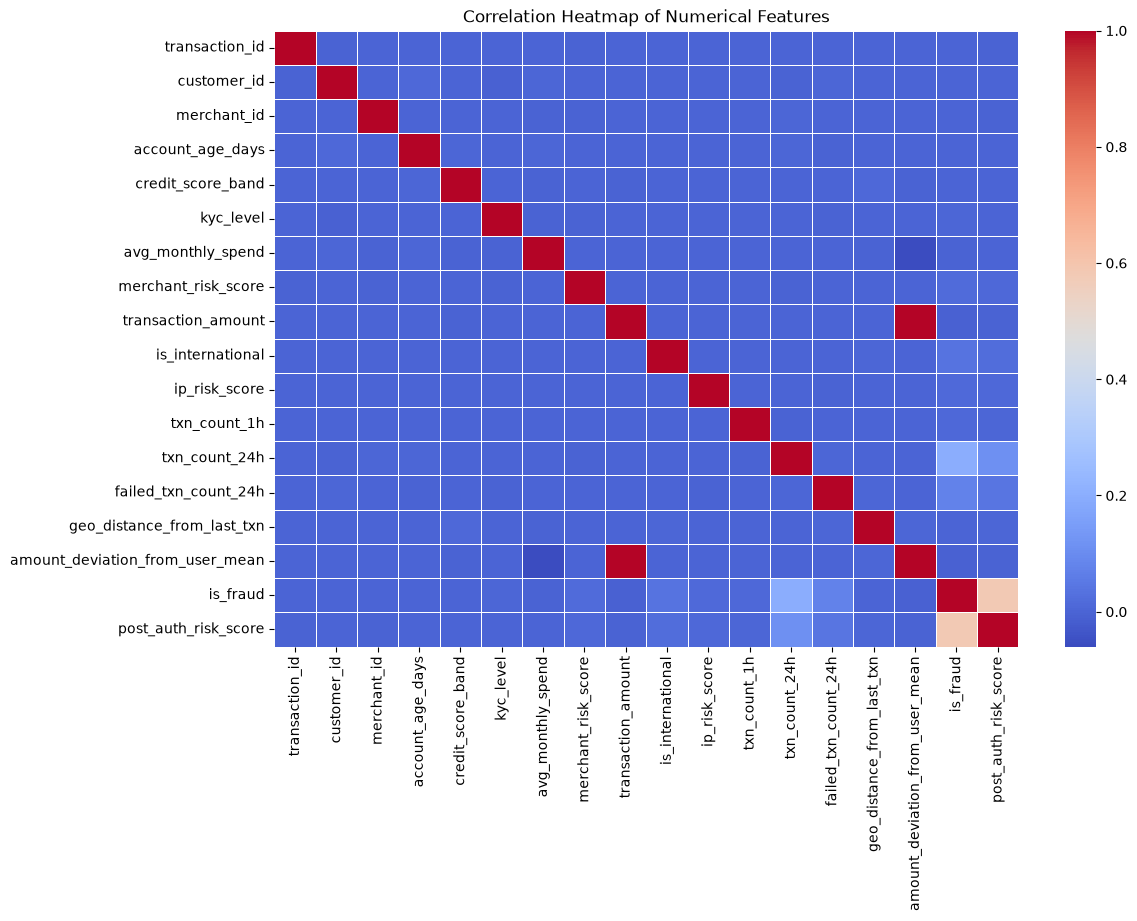

In [7]:
plt.figure(figsize=(12, 8))

# Selecting only numerical columns because correlation only works on numbers
numerical_cols = train_df.select_dtypes(include=['int64', 'float64']).columns
corr_matrix = train_df[numerical_cols].corr()

# Creating the heatmap
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()